In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/media/carsen/ssd1/github/oneshot')
from utils import data
mouse_ids = [7,8,10,11,12]
save_path = './result'
weight_path = '/home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights'

# helper functions

In [2]:
# ---------- helper ----------
def p_to_stars(p):
    if p < 1e-3: return '***'
    if p < 1e-2: return '**'
    if p < 5e-2: return '*'
    return 'n.s.'

def add_bracket(ax, x1, x2, y, h, text, lw=1):
    """Draws a significance bracket from x1 to x2 at height y with height h."""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, color='black')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=9)

# load data

In [ ]:
rfsize_all = []
fecv_all = []
fecv_model_all = []
layers_all = []
areas_all = []
feve_all = []
fev_all = []
mf_all = []
msigma_all = []
mtheta_all = []
planes_all = []
all_depth_feve = []
area_names = ['V1', 'medial']
layer_names = ['layer 1', 'layer 2/3']
mouse_id_all = []
gabor_feve_all = []
for i, mouse_id in enumerate(mouse_ids):
    res_dict = np.load(os.path.join(save_path, f'{data.mouse_names[mouse_id]}_{data.exp_date[mouse_id]}_fullmodel_result.npz'), allow_pickle=True)
    fev = res_dict['oneshot_sigvar'].astype(float)
    rf_size = res_dict['rf_size_visual'].astype(float)
    feve = res_dict['FEVE_fullmodel'].astype(float)
    fecv = res_dict['FECV'].astype(float)
    fecv[np.isnan(fecv)] = 0
    fecv_model = res_dict['FECV_model'].astype(float)
    fecv_model[np.isnan(fecv_model)] = 0
    ilayer = res_dict['ilayer'].astype(int)
    iarea = res_dict['iregion'].astype(int)
    gabor_mf = res_dict['gabor_mf'].astype(float)
    gabor_msigma = res_dict['gabor_msigma'].astype(float)
    gabor_mtheta = res_dict['gabor_mtheta'].astype(float)
    # depth_feve = res_dict['FEVE_all_depth'].astype(float) # (n_depth, n_neurons)
    ineur = res_dict['ineur'].astype(int)
    # all_depth_feve.append(depth_feve)
    rfsize_all.append(rf_size)
    fecv_all.append(fecv)
    fecv_model_all.append(fecv_model)
    feve_all.append(feve)
    fev_all.append(fev)
    layers_all.append(ilayer)
    areas_all.append(iarea)
    mf_all.append(gabor_mf)
    msigma_all.append(gabor_msigma)
    mtheta_all.append(gabor_mtheta)
    mouse_id_all.append(np.ones_like(rf_size)*mouse_id)
    gabor_path = os.path.join(weight_path, 'gabor', f'gabor_params_{data.db[mouse_id]["mname"]}_{data.db[mouse_id]["datexp"]}_more_f_sigma.npz')
    print('load gabor params from', gabor_path)
    result_dict = np.load(gabor_path, allow_pickle=True)
    gabor_feve = result_dict['feve'].astype(float)[ineur]
    gabor_feve_all.append(gabor_feve)
    print(len(rf_size))
rfsize_all = np.concatenate(rfsize_all)
fecv_all = np.concatenate(fecv_all)
fecv_model_all = np.concatenate(fecv_model_all)
feve_all = np.concatenate(feve_all)
fev_all = np.concatenate(fev_all)
layers_all = np.concatenate(layers_all)
areas_all = np.concatenate(areas_all)
mf_all = np.concatenate(mf_all)
msigma_all = np.concatenate(msigma_all)
mtheta_all = np.concatenate(mtheta_all)
# all_depth_feve = np.concatenate(all_depth_feve, axis=1) # (n_depth, n_neurons_total)
mouse_id_all = np.concatenate(mouse_id_all)
gabor_feve_all = np.concatenate(gabor_feve_all)

print(f'rfsize_all: {rfsize_all.shape}, fecv_all: {fecv_all.shape}, feve_all: {feve_all.shape}, fev_all: {fev_all.shape}, layers_all: {layers_all.shape}, areas_all: {areas_all.shape}, mf_all: {mf_all.shape}, msigma_all: {msigma_all.shape}, mtheta_all: {mtheta_all.shape}')

load gabor params from /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/gabor/gabor_params_FX41_2025_01_23_more_f_sigma.npz
5373
load gabor params from /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/gabor/gabor_params_FX43_2025_01_24_more_f_sigma.npz
5196
load gabor params from /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/gabor/gabor_params_FX41_2025_02_14_more_f_sigma.npz
5247
load gabor params from /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/gabor/gabor_params_FX41_2025_05_12_more_f_sigma.npz
3491
load gabor params from /home/carsen/dm11_cluster/fengtongd/Desktop/github/oneshot/weights/gabor/gabor_params_FX43_2025_05_19_more_f_sigma.npz
4180
rfsize_all: (23487,), fecv_all: (23487,), feve_all: (23487,), fev_all: (23487,), layers_all: (23487,), areas_all: (23487,), mf_all: (23487,), msigma_all: (23487,), mtheta_all: (23487,)


paired t-test between layers in area 0, t=-1.3941847499487943, p=0.2357155332880849
paired t-test between layers in area 1, t=0.7910025677852094, p=0.47320142554482797
paired t-test between areas, t=9.538057007951306, p=5.2968419795214654e-06


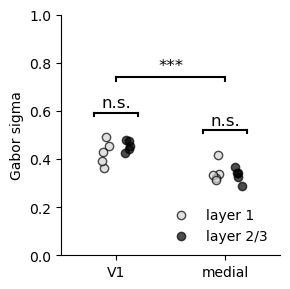

In [4]:
# plot the sigma 
nmouse = len(mouse_ids)
varplot = np.zeros((nmouse, 2, 2)) # mouse, area, layer
for i, mouse_id in enumerate(mouse_ids):
    for iarea in range(2):
        for ilayer in range(2):
            select = (mouse_id_all==mouse_id) & (areas_all==iarea) & (layers_all==ilayer+1)
            varplot[i, iarea, ilayer] = np.nanmean(mf_all[select])

fig, ax = plt.subplots(figsize=(3,3))
# scatter plot of each mouse, xaxies is V1 and medial, layer is with different color with a small shift in x axis
depth_colors = ['lightgray', 'black']
for ilayer in range(2):
    for iarea in range(2):
        ax.scatter(np.ones(nmouse)*iarea + (ilayer-0.5)*0.2 + np.random.randn(nmouse)*0.02, varplot[:, iarea, ilayer], color=depth_colors[ilayer], alpha=0.7, label=layer_names[ilayer] if iarea==0 else "", edgecolor='black')
        # plot the median
        # ax.scatter(iarea + (ilayer-0.5)*0.1, np.nanmedian(varplot[:, iarea, ilayer]), color=depth_colors[ilayer], s=100, edgecolor='black', marker='D')
from scipy import stats
for iarea in range(2):
    # stats of difference between layers with paired t-test
    t, p = stats.ttest_rel(varplot[:,iarea,0], varplot[:,iarea,1])
    print(f'paired t-test between layers in area {iarea}, t={t}, p={p}')
    # plot the stars for significance based on p value
    ymax = np.nanmax(varplot[:,iarea,:])+0.1
    ax.plot([iarea-0.2, iarea+0.2], [ymax, ymax], color='black')
    # plot the small bar 
    ax.plot([iarea-0.2, iarea-0.2], [ymax*0.98, ymax], color='black')
    ax.plot([iarea+0.2, iarea+0.2], [ymax*0.98, ymax], color='black')
    ax.text(iarea, ymax*1.02, p_to_stars(p), ha='center', va='bottom', color='black', fontsize=12)

t, p = stats.ttest_rel(varplot[:,0,:].flatten(), varplot[:,1,:].flatten())
print(f'paired t-test between areas, t={t}, p={p}')
ymax = np.nanmax(varplot)+0.25
ax.plot([0,1], [ymax, ymax], color='black')
ax.text(0.5, ymax*1.02, p_to_stars(p), ha='center', va='bottom', color='black', fontsize=12)
# plot the small bar
ax.plot([0,0], [ymax*0.98, ymax], color='black')
ax.plot([1,1], [ymax*0.98, ymax], color='black')

ax.set_xticks([0,1])
ax.set_xticklabels(area_names)
ax.set_ylabel('Gabor sigma')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([0, 1])
fig.tight_layout()

In [5]:
var_names = ['RF size(deg)', 'Gabor mf', 'Gabor sigma', 'Gabor theta', 'FEV', 'FEVE', 'FECV', 'Gabor FEVE', 'FECV model']
var_all = [rfsize_all, mf_all, msigma_all, mtheta_all, fev_all, feve_all, fecv_all, gabor_feve_all, fecv_model_all]
ymin_all = [0, 0, 0, 0, 0, 0, 0., 0, 0]
ymax_all = [50, 0.8, 10, 3, 0.5, 1.2, 0.01, 1, 0.1]

# get the top 10% FEV neurons in V1 and medial separately from each layer
# iv1 = (areas_all==0) & (fev_all >= np.percentile(fev_all[areas_all==0], 90))
# imedial = (areas_all==1) & (fev_all >= np.percentile(fev_all[areas_all==1], 90))
# ineurons = iv1 | imedial
# # ineurons = fev_all >= 0.15
# for i in range(len(var_all)):
#     var_all[i] = var_all[i][ineurons]

paired t-test between layers in area 0, t=1.5164479824025794, p=0.2039974146377816
paired t-test between layers in area 1, t=2.094907103140567, p=0.10425110249136678
paired t-test between areas, t=-4.905133773531349, p=0.0008416677527906561


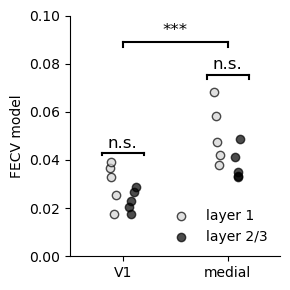

In [11]:
# plot the f
ivar = 8
nmouse = len(mouse_ids)
varplot = np.zeros((nmouse, 2, 2)) # mouse, area, layer
for i, mouse_id in enumerate(mouse_ids):
    for iarea in range(2):
        for ilayer in range(2):
            # select the top 10% FEV neurons in this area and layer for this mouse
            select = (mouse_id_all==mouse_id) & (areas_all==iarea) & (layers_all==ilayer+1)
            select = select & (fev_all >= np.percentile(fev_all[select], 90))
            varplot[i, iarea, ilayer] = np.nanmean(var_all[ivar][select])

fig, ax = plt.subplots(figsize=(3,3))
# scatter plot of each mouse, xaxies is V1 and medial, layer is with different color with a small shift in x axis
depth_colors = ['lightgray', 'black']
for ilayer in range(2):
    for iarea in range(2):
        ax.scatter(np.ones(nmouse)*iarea + (ilayer-0.5)*0.2 + np.random.randn(nmouse)*0.02, varplot[:, iarea, ilayer], color=depth_colors[ilayer], alpha=0.7, label=layer_names[ilayer] if iarea==0 else "", edgecolor='black')


for iarea in range(2):
    # stats of difference between layers with paired t-test
    t, p = stats.ttest_rel(varplot[:,iarea,0], varplot[:,iarea,1])
    print(f'paired t-test between layers in area {iarea}, t={t}, p={p}')
    # plot the stars for significance based on p value
    ymax = np.nanmax(varplot[:,iarea,:])*1.1
    ax.plot([iarea-0.2, iarea+0.2], [ymax, ymax], color='black')
    # plot the small bar 
    ax.plot([iarea-0.2, iarea-0.2], [ymax*0.98, ymax], color='black')
    ax.plot([iarea+0.2, iarea+0.2], [ymax*0.98, ymax], color='black')
    ax.text(iarea, ymax*1.02, p_to_stars(p), ha='center', va='bottom', color='black', fontsize=12)


t, p = stats.ttest_rel(varplot[:,0,:].flatten(), varplot[:,1,:].flatten())
print(f'paired t-test between areas, t={t}, p={p}')
ymax = np.nanmax(varplot)*1.3
ax.plot([0,1], [ymax, ymax], color='black')
ax.text(0.5, ymax*1.02, p_to_stars(p), ha='center', va='bottom', color='black', fontsize=12)
# plot the small bar
ax.plot([0,0], [ymax*0.98, ymax], color='black')
ax.plot([1,1], [ymax*0.98, ymax], color='black')

ax.set_xticks([0,1])
ax.set_xticklabels(area_names)
ax.set_ylabel(f'{var_names[ivar]}')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([-0.5, 1.5])
ax.set_ylim([ymin_all[ivar], ymax_all[ivar]])
fig.tight_layout()

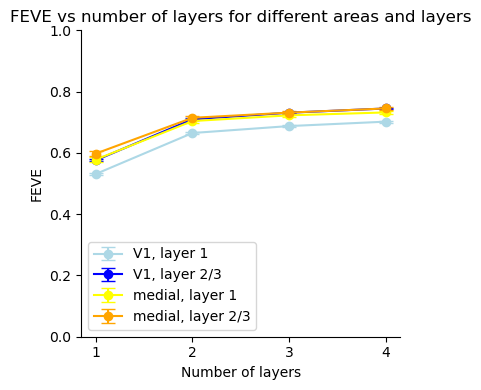

In [12]:
# plot all depth feve with different areas and layers
fig, ax = plt.subplots(1, 1, figsize=(4,4))
n_depth = all_depth_feve.shape[0]
depths = np.arange(1, n_depth+1)
colors = [['lightblue', 'blue'], ['yellow', 'orange']]
for iarea in range(2):
    area_name = 'V1' if iarea==0 else 'medial'
    for ilayer in range(2):
        color = colors[iarea][ilayer]
        indexes = np.where((areas_all==iarea) & (layers_all==(ilayer+1)))[0]
        layer_name = 'layer 1' if ilayer==0 else 'layer 2/3'
        feve_mean = np.mean(all_depth_feve[:, indexes], axis=1)
        # calculate sem
        feve_sem = np.std(all_depth_feve[:, indexes], axis=1) / np.sqrt(len(indexes))
        # plot with errorbar
        ax.errorbar(depths, feve_mean, yerr=feve_sem, marker='o', label=f'{area_name}, {layer_name}', capsize=5, color=color)
        # ax.plot(depths, feve_mean, marker='o', label=f'{area_name}, {layer_name}')
ax.set_xlabel('Number of layers')
ax.set_ylabel('FEVE')
ax.set_title('FEVE vs number of layers for different areas and layers')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(depths)
ax.set_ylim([0, 1])
ax.legend()
plt.tight_layout()